# Parameter Space Coverage

Assess how well the 52k baseline experiments cover the hyperparameter space:
1. **Marginal coverage** - Does every value of each hyperparameter appear?
2. **Pairwise coverage** - What fraction of value-pair combinations appear for each hyperparameter pair?
3. **Journey x hyperparameter coverage** - Is each hyperparameter value represented across all 72 journey configurations?
4. **Triple coverage** - What fraction of 3-way value combinations appear? Conditional pairwise heatmaps for any gaps.
5. **q-way coverage** - Combinatorial coverage strength from q=2 up to the full parameter set (excl. offspring_size).

In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import itertools
import warnings

warnings.filterwarnings("ignore")

In [2]:
gdf = gpd.read_parquet("../results/results_prelim.geoparquet")

# Filter to baseline scenario and best elite (n_elite == 0) to get one row per experiment
df = gdf[(gdf.forcing_scenario_name == "baseline") & (gdf.n_elite == 0)].copy()
print(f"Baseline experiments: {len(df)}")

Baseline experiments: 38338


In [3]:
# Tunable hyperparameters (excluding fixed values)
HYPER_COLS = [
    "hyper_population_size",
    "hyper_offspring_size",
    "hyper_generations",
    "hyper_mutation_iterations",
    "hyper_gd_iterations",
    "hyper_crossover_rounds",
    "hyper_crossover_strategy",
    "hyper_selection_quantile",
    "hyper_selection_acceptance_rate",
    "hyper_hazard_penalty_multiplier",
    "hyper_mutation_displacement_fraction_warmup",
    "hyper_enable_adaptation",
    "hyper_adaptation_scale_W",
    "hyper_adaptation_scale_D",
]

JOURNEY_COLS = [
    "journey_name",
    "journey_time_start",
    "journey_speed_knots",
]

## 1. Marginal Coverage

In [4]:
marginal = pd.DataFrame(
    {
        "unique_values": {col: sorted(df[col].dropna().unique()) for col in HYPER_COLS},
        "n_unique": {col: df[col].nunique() for col in HYPER_COLS},
        "n_samples": {col: df[col].notna().sum() for col in HYPER_COLS},
    }
)
marginal.index = marginal.index.str.removeprefix("hyper_")
marginal

,unique_values,n_unique,n_samples
population_size,"[64, 128, 256]",3,38338
offspring_size,"[16, 32, 64, 128, 256]",5,38338
generations,"[1, 4]",2,38338
mutation_iterations,"[1, 3]",2,38338
gd_iterations,"[0, 2]",2,38338
crossover_rounds,"[0, 1, 2]",3,38338
crossover_strategy,"[minimal_cost, random]",2,38338
selection_quantile,"[0.1, 0.25]",2,38338
selection_acceptance_rate,"[0.0, 0.25]",2,38338
hazard_penalty_multiplier,"[0.0, 100.0]",2,38338


## 2. Pairwise Coverage

In [5]:
pairs = list(itertools.combinations(HYPER_COLS, 2))

pairwise_records = []
for col_a, col_b in pairs:
    n_a = df[col_a].nunique()
    n_b = df[col_b].nunique()
    n_possible = n_a * n_b
    n_observed = df.groupby([col_a, col_b]).ngroups
    pairwise_records.append(
        {
            "param_a": col_a.removeprefix("hyper_"),
            "param_b": col_b.removeprefix("hyper_"),
            "n_possible": n_possible,
            "n_observed": n_observed,
            "coverage": n_observed / n_possible,
        }
    )

df_pairs = pd.DataFrame(pairwise_records)
print(f"Total pairs: {len(df_pairs)}")
print(f"Full coverage (100%): {(df_pairs.coverage == 1.0).sum()}")
print(f"Min coverage: {df_pairs.coverage.min():.1%}")
print(f"Mean coverage: {df_pairs.coverage.mean():.1%}")

Total pairs: 91
Full coverage (100%): 90
Min coverage: 60.0%
Mean coverage: 99.6%


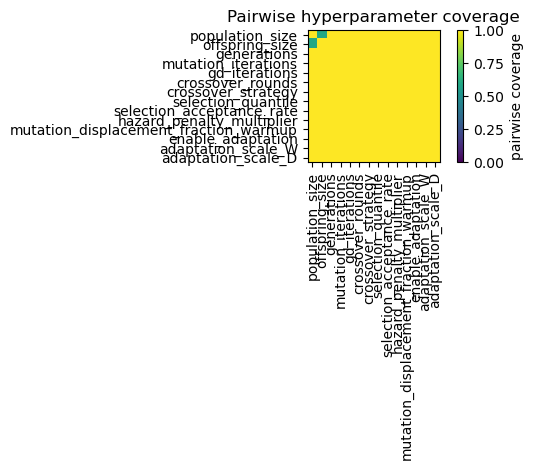

In [6]:
# Pairwise coverage as heatmap
short_names = [c.removeprefix("hyper_") for c in HYPER_COLS]
coverage_matrix = pd.DataFrame(1.0, index=short_names, columns=short_names)

for _, row in df_pairs.iterrows():
    coverage_matrix.loc[row.param_a, row.param_b] = row.coverage
    coverage_matrix.loc[row.param_b, row.param_a] = row.coverage

fig, ax = plt.subplots()
im = ax.imshow(coverage_matrix.values, vmin=0, vmax=1, cmap="viridis")
ax.set_xticks(range(len(short_names)))
ax.set_yticks(range(len(short_names)))
ax.set_xticklabels(short_names, rotation=90)
ax.set_yticklabels(short_names)
plt.colorbar(im, ax=ax, label="pairwise coverage")
ax.set_title("Pairwise hyperparameter coverage")
plt.tight_layout()
plt.savefig("../figures/011_pairwise_coverage.png")
plt.savefig("../figures/011_pairwise_coverage.pdf")

In [7]:
# Pairs with lowest coverage
df_pairs.sort_values("coverage").head(10)

,param_a,param_b,n_possible,n_observed,coverage
0,population_size,offspring_size,15,9,0.6
65,crossover_strategy,hazard_penalty_multiplier,4,4,1.0
64,crossover_strategy,selection_acceptance_rate,4,4,1.0
63,crossover_strategy,selection_quantile,4,4,1.0
62,crossover_rounds,adaptation_scale_D,6,6,1.0
61,crossover_rounds,adaptation_scale_W,6,6,1.0
60,crossover_rounds,enable_adaptation,6,6,1.0
59,crossover_rounds,mutation_displacement_fraction_warmup,6,6,1.0
58,crossover_rounds,hazard_penalty_multiplier,6,6,1.0
57,crossover_rounds,selection_acceptance_rate,6,6,1.0


## 3. Journey x Hyperparameter Coverage

In [8]:
# For each journey config (name x month x speed), what fraction of each
# hyperparameter's values are represented?
df["journey_month"] = pd.to_datetime(df.journey_time_start.astype(str)).dt.month
journey_group = ["journey_name", "journey_month", "journey_speed_knots"]

journey_hyper_records = []
for col in HYPER_COLS:
    n_values = df[col].nunique()
    coverage_per_journey = (
        df.groupby(journey_group)[col].nunique() / n_values
    )
    journey_hyper_records.append(
        {
            "param": col.removeprefix("hyper_"),
            "n_values": n_values,
            "min_coverage": coverage_per_journey.min(),
            "mean_coverage": coverage_per_journey.mean(),
            "max_coverage": coverage_per_journey.max(),
            "n_journeys_full": (coverage_per_journey == 1.0).sum(),
            "n_journeys_total": len(coverage_per_journey),
        }
    )

df_jh = pd.DataFrame(journey_hyper_records).set_index("param")
df_jh

,n_values,min_coverage,mean_coverage,max_coverage,n_journeys_full,n_journeys_total
param,,,,,,
population_size,3,1.0,1.0,1.0,72,72
offspring_size,5,1.0,1.0,1.0,72,72
generations,2,1.0,1.0,1.0,72,72
mutation_iterations,2,1.0,1.0,1.0,72,72
gd_iterations,2,1.0,1.0,1.0,72,72
crossover_rounds,3,1.0,1.0,1.0,72,72
crossover_strategy,2,1.0,1.0,1.0,72,72
selection_quantile,2,1.0,1.0,1.0,72,72
selection_acceptance_rate,2,1.0,1.0,1.0,72,72


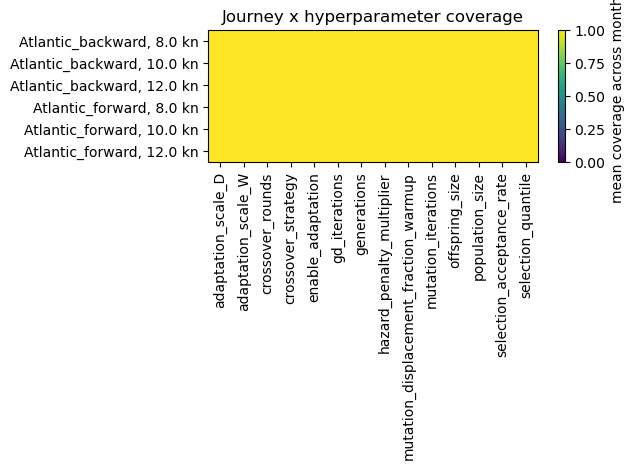

In [9]:
# Heatmap: journey configs x hyperparameters, showing coverage fraction
# Aggregate by speed (rows) and hyperparameter (columns), averaging over months and directions
coverage_by_speed = []
for col in HYPER_COLS:
    n_values = df[col].nunique()
    cov = df.groupby(journey_group)[col].nunique() / n_values
    cov = cov.reset_index(name="coverage")
    cov["param"] = col.removeprefix("hyper_")
    coverage_by_speed.append(cov)

df_cov = pd.concat(coverage_by_speed)

pivot = df_cov.pivot_table(
    index=["journey_name", "journey_speed_knots"],
    columns="param",
    values="coverage",
    aggfunc="mean",
)

fig, ax = plt.subplots()
im = ax.imshow(pivot.values, vmin=0, vmax=1, cmap="viridis", aspect="auto")
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns, rotation=90)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels([f"{n}, {s} kn" for n, s in pivot.index])
plt.colorbar(im, ax=ax, label="mean coverage across months")
ax.set_title("Journey x hyperparameter coverage")
plt.tight_layout()
plt.savefig("../figures/011_journey_hyper_coverage.png")
plt.savefig("../figures/011_journey_hyper_coverage.pdf")

In [10]:
# Samples per journey configuration
samples_per_journey = df.groupby(journey_group).size()
print(f"Samples per journey config:")
print(f"  min:    {samples_per_journey.min()}")
print(f"  median: {samples_per_journey.median():.0f}")
print(f"  max:    {samples_per_journey.max()}")

Samples per journey config:
  min:    424
  median: 546
  max:    619


## 4. Triple Coverage

In [11]:
triples = list(itertools.combinations(HYPER_COLS, 3))

triple_records = []
for col_a, col_b, col_c in triples:
    n_possible = df[col_a].nunique() * df[col_b].nunique() * df[col_c].nunique()
    n_observed = df.groupby([col_a, col_b, col_c]).ngroups
    triple_records.append(
        {
            "param_a": col_a.removeprefix("hyper_"),
            "param_b": col_b.removeprefix("hyper_"),
            "param_c": col_c.removeprefix("hyper_"),
            "n_possible": n_possible,
            "n_observed": n_observed,
            "coverage": n_observed / n_possible,
        }
    )

df_triples = pd.DataFrame(triple_records)
print(f"Total triples: {len(df_triples)}")
print(f"Full coverage (100%): {(df_triples.coverage == 1.0).sum()}")
print(f"Below 100%: {(df_triples.coverage < 1.0).sum()}")
print(f"Min coverage: {df_triples.coverage.min():.1%}")
print(f"Mean coverage: {df_triples.coverage.mean():.1%}")

Total triples: 364
Full coverage (100%): 352
Below 100%: 12
Min coverage: 60.0%
Mean coverage: 98.7%


In [12]:
# Triples with incomplete coverage
df_incomplete = df_triples[df_triples.coverage < 1.0].sort_values("coverage")
df_incomplete

,param_a,param_b,param_c,n_possible,n_observed,coverage
0,population_size,offspring_size,generations,30,18,0.6
1,population_size,offspring_size,mutation_iterations,30,18,0.6
2,population_size,offspring_size,gd_iterations,30,18,0.6
3,population_size,offspring_size,crossover_rounds,45,27,0.6
4,population_size,offspring_size,crossover_strategy,30,18,0.6
5,population_size,offspring_size,selection_quantile,30,18,0.6
6,population_size,offspring_size,selection_acceptance_rate,30,18,0.6
7,population_size,offspring_size,hazard_penalty_multiplier,30,18,0.6
8,population_size,offspring_size,mutation_displacement_fraction_warmup,30,18,0.6
9,population_size,offspring_size,enable_adaptation,30,18,0.6


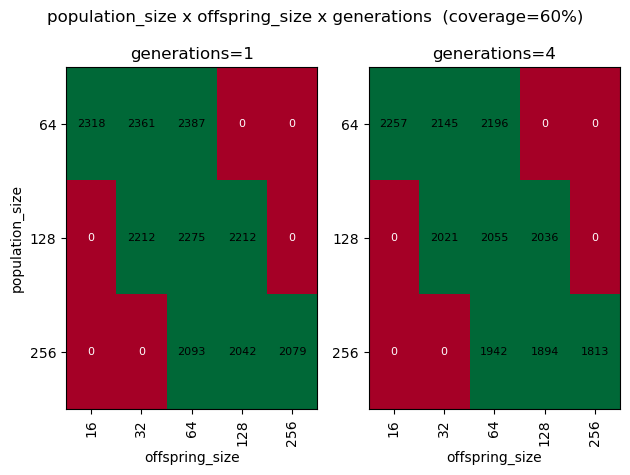

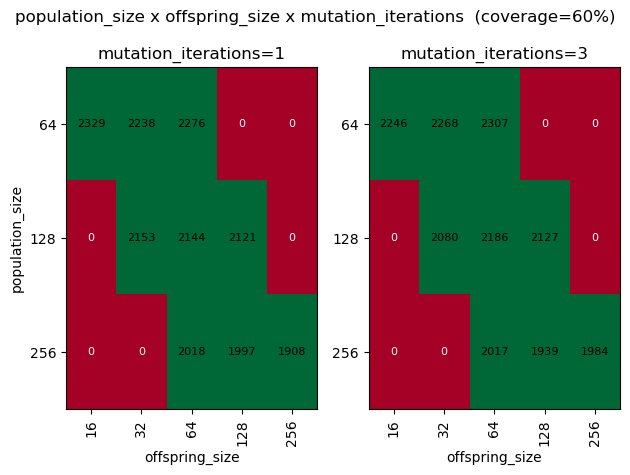

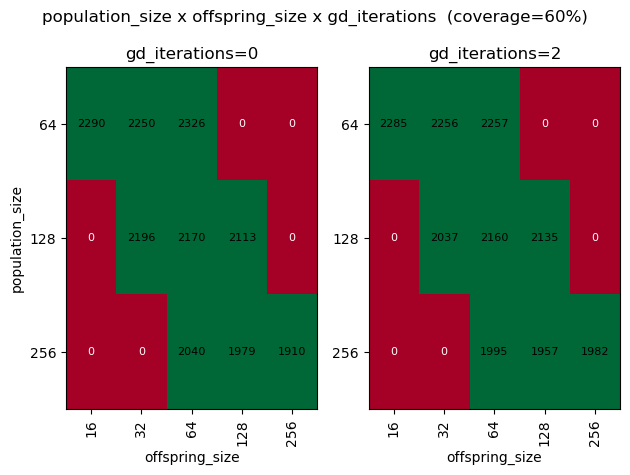

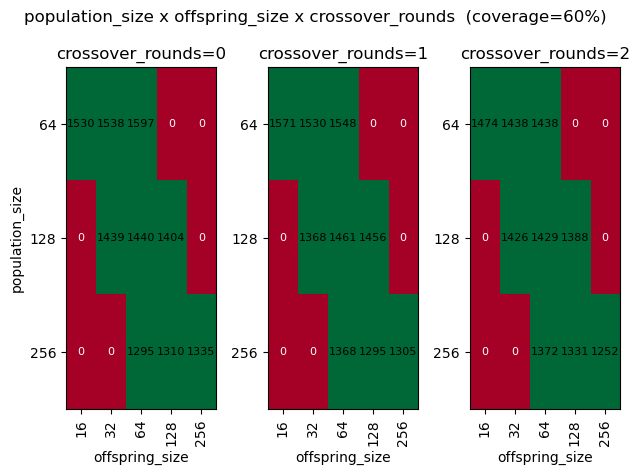

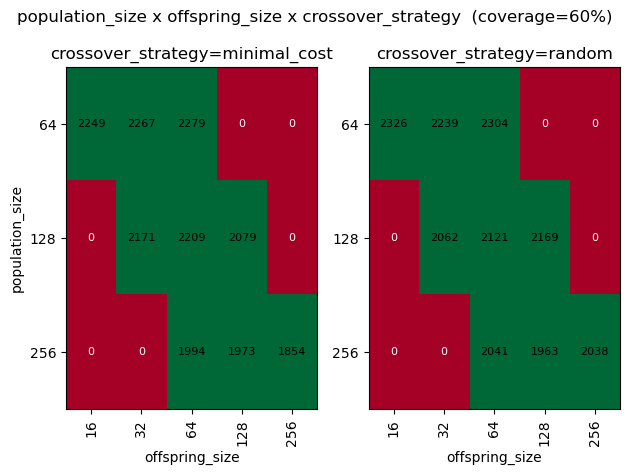

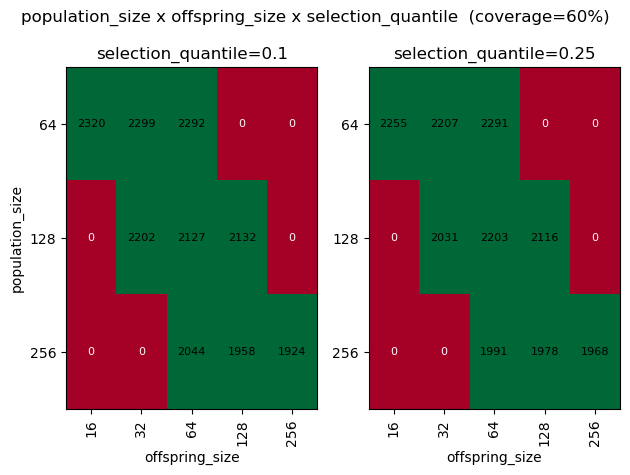

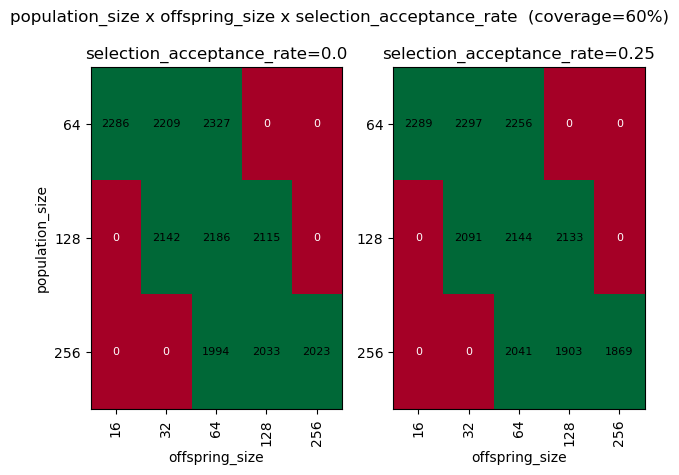

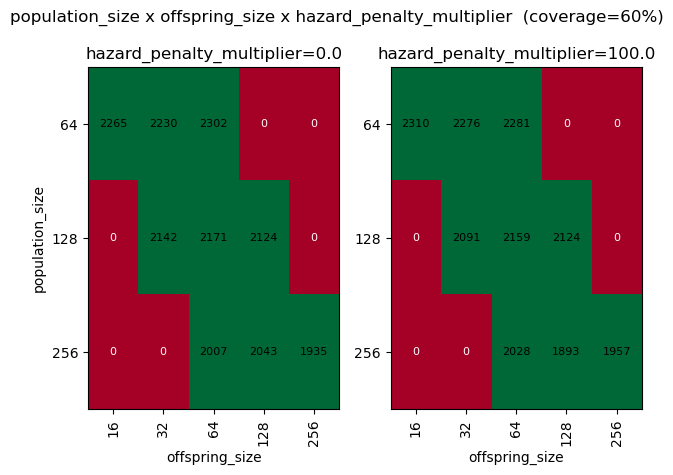

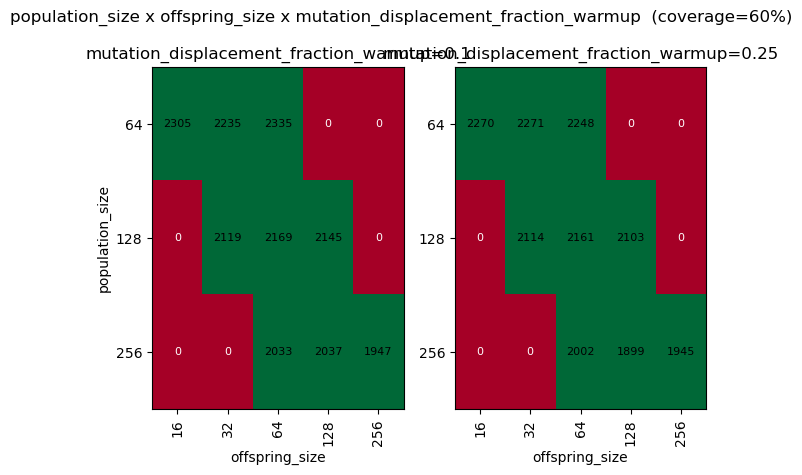

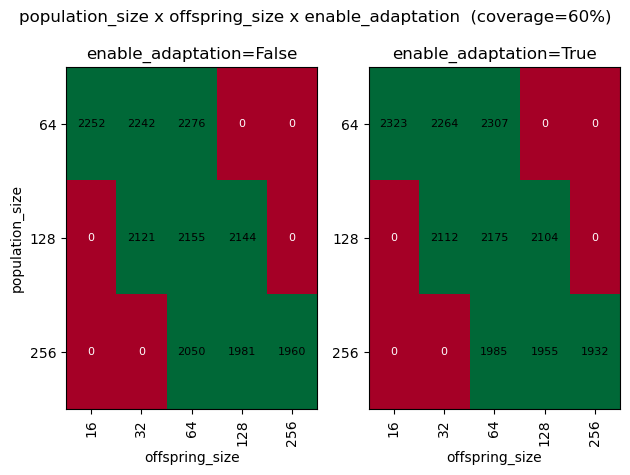

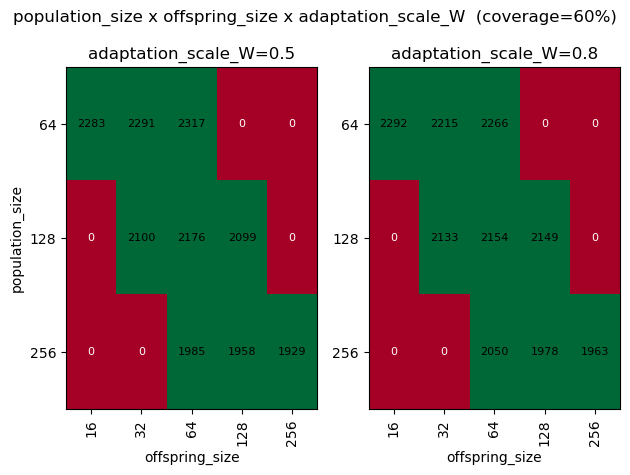

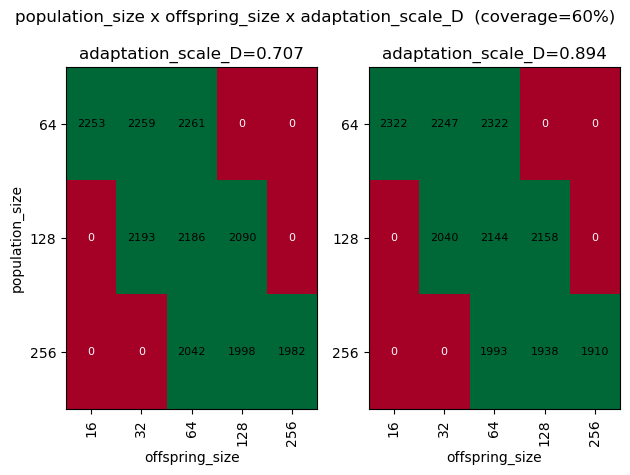

In [13]:
# Conditional pairwise heatmaps for incomplete triples
# For each incomplete triple (A, B, C), show one panel per value of C
# with A x B hit counts

if len(df_incomplete) > 0:
    for _, trow in df_incomplete.iterrows():
        col_a = "hyper_" + trow.param_a
        col_b = "hyper_" + trow.param_b
        col_c = "hyper_" + trow.param_c

        c_values = sorted(df[col_c].unique())
        n_panels = len(c_values)

        fig, axes = plt.subplots(1, n_panels, squeeze=False)
        axes = axes[0]

        for i, c_val in enumerate(c_values):
            ax = axes[i]
            df_sub = df[df[col_c] == c_val]
            ct = df_sub.groupby([col_a, col_b]).size().unstack(fill_value=0)
            # Reindex to show all possible values
            a_vals = sorted(df[col_a].unique())
            b_vals = sorted(df[col_b].unique())
            ct = ct.reindex(index=a_vals, columns=b_vals, fill_value=0)

            im = ax.imshow(ct.values > 0, cmap="RdYlGn", vmin=0, vmax=1, aspect="auto")
            # Annotate with counts
            for ri in range(len(a_vals)):
                for ci in range(len(b_vals)):
                    val = ct.values[ri, ci]
                    ax.text(ci, ri, str(int(val)), ha="center", va="center",
                            color="white" if val == 0 else "black", fontsize=8)

            ax.set_xticks(range(len(b_vals)))
            ax.set_xticklabels([str(v) for v in b_vals], rotation=90)
            ax.set_yticks(range(len(a_vals)))
            ax.set_yticklabels([str(v) for v in a_vals])
            ax.set_xlabel(trow.param_b)
            if i == 0:
                ax.set_ylabel(trow.param_a)
            ax.set_title(f"{trow.param_c}={c_val}")

        fig.suptitle(
            f"{trow.param_a} x {trow.param_b} x {trow.param_c}  "
            f"(coverage={trow.coverage:.0%})"
        )
        plt.tight_layout()
        plt.savefig(f"../figures/011_triple_{trow.param_a}_{trow.param_b}_{trow.param_c}.png")
        plt.savefig(f"../figures/011_triple_{trow.param_a}_{trow.param_b}_{trow.param_c}.pdf")
else:
    print("All triples have full coverage.")

## 5. q-way Coverage

Compute combinatorial coverage strength for q = 2, 3, ..., up to the full parameter set.
Excludes `offspring_size` (structurally coupled to `population_size`).

In [ ]:
# Exclude offspring_size (structurally dependent on population_size)
HYPER_COLS_INDEP = [c for c in HYPER_COLS if c != "hyper_offspring_size"]
print(f"Independent hyperparameters: {len(HYPER_COLS_INDEP)}")

q_max = len(HYPER_COLS_INDEP)
q_summary = []

for q in range(2, q_max + 1):
    subsets = list(itertools.combinations(HYPER_COLS_INDEP, q))
    coverages = []
    for subset in subsets:
        n_possible = 1
        for col in subset:
            n_possible *= df[col].nunique()
        n_observed = df.groupby(list(subset)).ngroups
        coverages.append(n_observed / n_possible)
    coverages = np.array(coverages)
    q_summary.append(
        {
            "q": q,
            "n_subsets": len(subsets),
            "n_possible_max": max(
                np.prod([df[c].nunique() for c in s])
                for s in subsets
            ),
            "coverage_min": coverages.min(),
            "coverage_q25": np.percentile(coverages, 25),
            "coverage_median": np.median(coverages),
            "coverage_q75": np.percentile(coverages, 75),
            "coverage_mean": coverages.mean(),
            "coverage_max": coverages.max(),
            "n_full": (coverages == 1.0).sum(),
        }
    )
    print(f"q={q:2d}: {len(subsets):5d} subsets, "
          f"coverage min={coverages.min():.1%} median={np.median(coverages):.1%} "
          f"mean={coverages.mean():.1%} max={coverages.max():.1%} "
          f"full={int((coverages == 1.0).sum())}/{len(subsets)}")

df_qcov = pd.DataFrame(q_summary).set_index("q")

In [ ]:
fig, ax = plt.subplots()
ax.fill_between(df_qcov.index, df_qcov.coverage_q25, df_qcov.coverage_q75, alpha=0.3)
ax.plot(df_qcov.index, df_qcov.coverage_median, "o-", label="median")
ax.plot(df_qcov.index, df_qcov.coverage_min, "v--", label="min")
ax.plot(df_qcov.index, df_qcov.coverage_mean, "s:", label="mean")
ax.set_xlabel("q (combination order)")
ax.set_ylabel("coverage fraction")
ax.set_title("q-way combinatorial coverage (excl. offspring_size)")
ax.set_ylim(0, 1.05)
ax.set_xticks(df_qcov.index)
ax.legend()
plt.tight_layout()
plt.savefig("../figures/011_qway_coverage.png")
plt.savefig("../figures/011_qway_coverage.pdf")